# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

**Authors**:<br> Luís Forti - 3981932
<br> Marcell Slyuch - 3992616
<br> Ntando Thato Mazinyane - 3987639 <br> <br>
In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [1]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn
# %pip install scipy
# %pip install scikit-learn

In [2]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
import os
import random

warnings.filterwarnings("ignore", module=r"matplotlib\..*")

## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [3]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [4]:
# The dataset may be located in different places depending on your setup.
# We try a few common locations and use the first one that exists.
candidate_locations = [
    "credit-a.arff",                                                    # same folder as the notebook
    os.path.join("Datasets", "Datasets", "uci-large", "credit-a.arff"), # original lab layout
    os.path.join("Datasets", "uci-large", "credit-a.arff"),
    os.path.join("uci-large", "credit-a.arff"),
]

path = next((p for p in candidate_locations if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError("credit-a.arff not found - adjust 'candidate_locations' to point to the file.")

# Load the arff file and print the meta information
data, meta = load_arff(path)
print(meta)

Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [6]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [7]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [8]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

In [9]:
# Exclude the class label variable
nominal = nominal[0:-1]
# Show how the one hot encoding looks
pd.get_dummies(data[nominal[0]])

,?,a,b
0,False,False,True
1,False,True,False
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
685,False,False,True
686,False,True,False
687,False,True,False
688,False,False,True


In [10]:
# create one hot encoding for all variables
dummies = pd.get_dummies(data[nominal])
# Concatenate with df and drop nominal columns
data = pd.concat([data, dummies], axis=1).drop(nominal, axis=1)

# remove the the encodings that end with ? since they contain only 0
data.drop([col for col in data.columns if col.endswith('_?')], axis=1, inplace=True)
data.head()

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1.0,202.0,0.0,+,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6.0,43.0,560.0,+,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0.0,280.0,824.0,+,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5.0,100.0,3.0,+,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0.0,120.0,0.0,+,False,True,False,...,False,False,True,True,False,True,False,False,False,True


After the one hot encoding, our dataframe contains 47 columns.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666 entries, 0 to 689
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      666 non-null    float64
 1   A3      666 non-null    float64
 2   A8      666 non-null    float64
 3   A11     666 non-null    float64
 4   A14     666 non-null    float64
 5   A15     666 non-null    float64
 6   class   666 non-null    object 
 7   A1_a    666 non-null    bool   
 8   A1_b    666 non-null    bool   
 9   A4_l    666 non-null    bool   
 10  A4_u    666 non-null    bool   
 11  A4_y    666 non-null    bool   
 12  A5_g    666 non-null    bool   
 13  A5_gg   666 non-null    bool   
 14  A5_p    666 non-null    bool   
 15  A6_aa   666 non-null    bool   
 16  A6_c    666 non-null    bool   
 17  A6_cc   666 non-null    bool   
 18  A6_d    666 non-null    bool   
 19  A6_e    666 non-null    bool   
 20  A6_ff   666 non-null    bool   
 21  A6_i    666 non-null    bool   
 22  A6_j   

In [12]:
# List of all the columns in our data, remove class variable
col = list(data.columns)
col.remove('class')
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s']


## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [13]:
# Seperate the input features from the class labels
X = data[input_features]
y = data['class']

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                    test_size=0.3,
                                                    random_state=100)

### Train the Naive Bayes Classifier
The model we choose here is a gaussian naive bayes classifier with default settings.

In [15]:
from sklearn.naive_bayes import GaussianNB
 
# Define the model
classifier = GaussianNB()
 
# Fit data to the classifier
classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## Model Evaluation: Classification
For the evaluation of our classification model, we will look at the **precision**, **recall** and **f1-score**. Additionally, we will plot the **confusion matrix**. 

In [16]:
# Importing required modules
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_classification(y_test, y_pred):
    # Print the standart evaluation metrics
    class_report = classification_report(y_test, y_pred)
    print(class_report)
    # Plot the confusion matrix
    plt.figure(figsize=(7,5))
    plt.title("Confusion Matrix", fontsize=18)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True)
    
    return class_report, cm

              precision    recall  f1-score   support

           +       0.82      0.80      0.81        93
           -       0.83      0.85      0.84       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



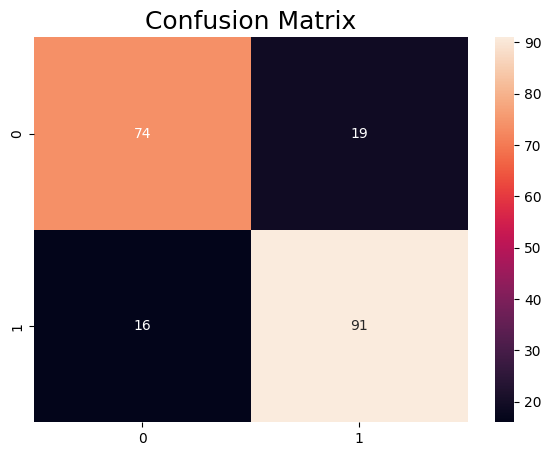

In [17]:
# Get the predictions from the classifier
y_pred = classifier.predict(X_test)

# Evaluate the classifier
class_report, conf_mat = evaluate_classification(y_test, y_pred)

---
# Exercise 1 &mdash; [Easy] Experiment: "Effect of random noise in input features on classification"

**Group:** 8 &nbsp;&nbsp;<br> **Names - student numbers:** <br>
Luís Forti - 3981932 <br>
Marcell Slyuch - 3992616 <br>
Ntando Thato Mazinyane - 3987639 <br>

**Aim.** Everything above this line is the *baseline*: a Gaussian Naive&nbsp;Bayes model
trained on the clean credit-approval data. In this experiment we study one data-quality
problem in isolation &mdash; **random noise in a single input feature** (data-entry slips,
sensor glitches, transcription errors: corruption that is unrelated to anything else).
We corrupt one feature with increasing amounts of noise, retrain and re-evaluate at each
level, and plot performance against the noise level. The questions we want to answer:

* How fast does classification performance drop as one feature gets noisier?
* Is the decline gradual, or is there a threshold beyond which it collapses?
* How clean does a feature realistically need to be for this model to still work?

**Method**

1. Keep the baseline code above untouched; record its performance as the 0&nbsp;% point.
2. Pick one attribute. If numeric, note its min/max; if categorical, list its values.
3. Loop over several noise levels (5&nbsp;%, 10&nbsp;%, 20&nbsp;%, 50&nbsp;%, &hellip;).
4. At each level, pick that fraction of **all rows** at random and replace *only* that
   attribute's value with a random one (uniform in `[min, max]` if numeric, a random
   category if categorical). Use freshly drawn rows for every level.
5. Train and evaluate exactly as in the baseline.
6. Plot the results with the baseline as the 0&nbsp;% point.

## Reusable pipeline

A clean, un-encoded copy of the data plus the baseline preprocessing wrapped in a function, so we can re-run it on a corrupted copy. The train/test split is fixed by `random_state`, so **only the injected noise changes** between experiments.

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Rebuild a CLEAN, un-encoded copy of the data, independent of the cells above.
# `load_arff` and `path` were defined in the beginning of the notebook.
_raw_arff, _meta = load_arff(path)
RAW = _raw_arff.dropna().reset_index(drop=True)

# Newer scipy/pandas may hand back nominal columns as bytes; decode only if needed.
def _decode_if_bytes(v):
    return v.decode() if isinstance(v, bytes) else v

for _c in RAW.columns:
    if not pd.api.types.is_numeric_dtype(RAW[_c]):
        RAW[_c] = RAW[_c].map(_decode_if_bytes)

NUMERIC = [c for c in RAW.columns if pd.api.types.is_numeric_dtype(RAW[c])]
NOMINAL = [c for c in RAW.columns
           if not pd.api.types.is_numeric_dtype(RAW[c]) and c != "class"]

print(f"{len(RAW)} rows after dropping NaNs")
print("numeric features :", NUMERIC)
print("nominal features :", NOMINAL)

666 rows after dropping NaNs
numeric features : ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
nominal features : ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


In [19]:
def preprocess_and_split(df, random_state=100):
    """Baseline preprocessing (one-hot encode nominal columns, drop the all-zero
    '_?' dummy columns) followed by the same 70/30 split as the baseline. Because
    random_state is fixed, the partition is identical on every call."""
    dummies = pd.get_dummies(df[NOMINAL])
    enc = pd.concat([df, dummies], axis=1).drop(columns=NOMINAL)
    enc = enc.drop(columns=[c for c in enc.columns if c.endswith("_?")])
    features = [c for c in enc.columns if c != "class"]
    return train_test_split(enc[features], enc["class"],
                            train_size=0.7, test_size=0.3, random_state=random_state)


def train_eval(df):
    """Train Gaussian Naive Bayes on a (possibly corrupted) copy of the data and
    return the test-set scores."""
    X_train, X_test, y_train, y_test = preprocess_and_split(df)
    model = GaussianNB().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1_pos":    f1_score(y_test, y_pred, pos_label="+"),
        "f1_macro":  f1_score(y_test, y_pred, average="macro"),
    }


# Sanity check: this must reproduce the baseline numbers from the cells above.
print("baseline (no noise):", {k: round(v, 4) for k, v in train_eval(RAW).items()})


baseline (no noise): {'accuracy': 0.825, 'f1_pos': 0.8087, 'f1_macro': 0.8237}


## Step 1 &mdash; choose the feature to corrupt and characterise it

`A9` (*prior default*) is a strong `t`/`f` predictor, so the effect is easy to see.

In [20]:
# ----------------------------- configuration ------------------------------
TARGET       = "A9"           # feature to corrupt
NOISE_LEVELS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]
N_REPEATS    = 100            # random draws per noise level, averaged for a smooth trend
BASE_SEED    = 42
# ------------------------------------------------------------------------

TARGET_IS_NUMERIC = pd.api.types.is_numeric_dtype(RAW[TARGET])

if TARGET_IS_NUMERIC:
    T_MIN, T_MAX = float(RAW[TARGET].min()), float(RAW[TARGET].max())
    VALUE_POOL = None
    print(f"{TARGET} is numeric  ->  replacements drawn uniformly from [{T_MIN}, {T_MAX}]")
else:
    VALUE_POOL = sorted(v for v in RAW[TARGET].unique() if v != "?")
    T_MIN = T_MAX = None
    print(f"{TARGET} is categorical  ->  replacements drawn uniformly from {VALUE_POOL}")

A9 is categorical  ->  replacements drawn uniformly from ['f', 't']


## Step 2 &mdash; the noise-injection function

In [21]:
def add_random_noise(df, frac, rng):
    """Return a copy of `df` in which `frac` of ALL rows have their TARGET value
    replaced by a random value:
      * numeric      -> uniform in [T_MIN, T_MAX]
      * categorical  -> uniform over VALUE_POOL
    The whole dataset is corrupted here, before the train/test split, as the
    assignment specifies for this experiment."""
    if frac <= 0:
        return df
    df = df.copy()
    n = int(round(frac * len(df)))
    idx = rng.choice(df.index.to_numpy(), size=n, replace=False)
    if TARGET_IS_NUMERIC:
        df.loc[idx, TARGET] = rng.uniform(T_MIN, T_MAX, size=n)
    else:
        df.loc[idx, TARGET] = rng.choice(VALUE_POOL, size=n)
    return df

## Step 3 &mdash; run the sweep

For each noise level we corrupt the data `N_REPEATS` times with different random rows/values and evaluate each time. The 0&nbsp;% level is deterministic, so it is run once.

In [22]:
records = []
for frac in NOISE_LEVELS:
    n_rep = 1 if frac == 0.0 else N_REPEATS
    for r in range(n_rep):
        rng = np.random.default_rng((BASE_SEED, int(round(frac * 1000)), r))
        scores = train_eval(add_random_noise(RAW, frac, rng))
        records.append({"noise": frac, "repeat": r, **scores})

results = pd.DataFrame(records)
summary = results.groupby("noise").agg(["mean", "min", "max"])
summary.round(4)

repeat         accuracy                f1_pos                 f1_macro  \
        mean min max     mean    min    max    mean     min     max     mean   
noise                                                                          
0.00     0.0   0   0   0.8250  0.825  0.825  0.8087  0.8087  0.8087   0.8237   
0.05    49.5   0  99   0.8192  0.800  0.830  0.8020  0.7802  0.8132   0.8179   
0.10    49.5   0  99   0.8176  0.790  0.830  0.7999  0.7692  0.8152   0.8162   
0.20    49.5   0  99   0.8050  0.780  0.830  0.7827  0.7528  0.8132   0.8029   
0.30    49.5   0  99   0.7983  0.765  0.825  0.7730  0.7345  0.8045   0.7957   
0.50    49.5   0  99   0.7920  0.765  0.815  0.7660  0.7283  0.7933   0.7893   
0.75    49.5   0  99   0.7701  0.745  0.795  0.7408  0.7119  0.7709   0.7671   
1.00    49.5   0  99   0.7561  0.745  0.765  0.7253  0.7119  0.7374   0.7530   

                       
          min     max  
noise                  
0.00   0.8237  0.8237  
0.05   0.7984  0.8286  
0.10   0.7883  0.8289  
0.20   0.7773  0.8286  
0.30   0.7619  0.8230  
0.50   0.7606  0.8129  
0.75   0.7416  0.7927  
1.00   0.7416  0.7624

## Step 4 &mdash; plot performance vs. noise level

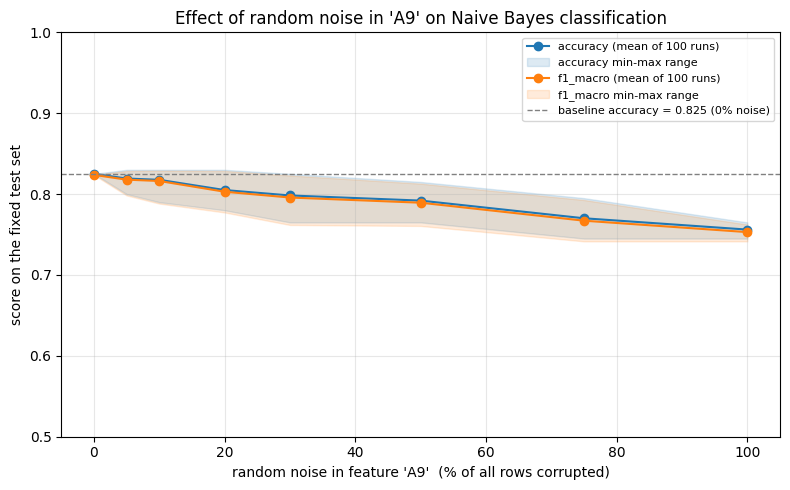

In [23]:
metrics = [("accuracy", "tab:blue"), ("f1_macro", "tab:orange")]
x = summary.index.to_numpy() * 100          # noise level as a percentage

fig, ax = plt.subplots(figsize=(8, 5))
for name, colour in metrics:
    mean = summary[(name, "mean")].to_numpy()
    lo   = summary[(name, "min")].to_numpy()
    hi   = summary[(name, "max")].to_numpy()
    ax.plot(x, mean, marker="o", color=colour,
            label=f"{name} (mean of {N_REPEATS} runs)")
    ax.fill_between(x, lo, hi, color=colour, alpha=0.15,
                   label=f"{name} min-max range")

baseline_acc = summary[("accuracy", "mean")].iloc[0]
ax.axhline(baseline_acc, ls="--", c="gray", lw=1,
           label=f"baseline accuracy = {baseline_acc:.3f} (0% noise)")

ax.set_xlabel(f"random noise in feature '{TARGET}'  (% of all rows corrupted)")
ax.set_ylabel("score on the fixed test set")
ax.set_title(f"Effect of random noise in '{TARGET}' on Naive Bayes classification")
ax.set_ylim(bottom=min(0.5, summary[("f1_macro", "min")].min() - 0.05), top=1.0)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Which attribute matters most? &mdash; feature-importance analysis

**Permutation importance** &mdash; shuffle one attribute (leaving everything else
intact), retrain, and measure how much test performance drops. This is the noise
experiment taken to its extreme &mdash; a fully shuffled column is 100&nbsp;% noise
&mdash; so it justifies our choice of `A9` as the corruption target: it is by far
the attribute this model relies on most.

In [24]:
from scipy import stats

FEATURES = [c for c in RAW.columns if c != "class"]


def train_eval_cols(df, random_state=100):
    """Like train_eval, but recomputes the nominal-column list from `df` so it also
    works when an attribute has been dropped."""
    nom = [c for c in df.columns
           if not pd.api.types.is_numeric_dtype(df[c]) and c != "class"]
    dummies = pd.get_dummies(df[nom])
    enc = pd.concat([df, dummies], axis=1).drop(columns=nom)
    enc = enc.drop(columns=[c for c in enc.columns if c.endswith("_?")])
    feats = [c for c in enc.columns if c != "class"]
    Xtr, Xte, ytr, yte = train_test_split(enc[feats], enc["class"],
                                          train_size=0.7, test_size=0.3,
                                          random_state=random_state)
    model = GaussianNB().fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {"accuracy":  accuracy_score(yte, pred),
            "f1_macro":  f1_score(yte, pred, average="macro")}

baseline accuracy = 0.825   (positive drop = attribute helps the model)


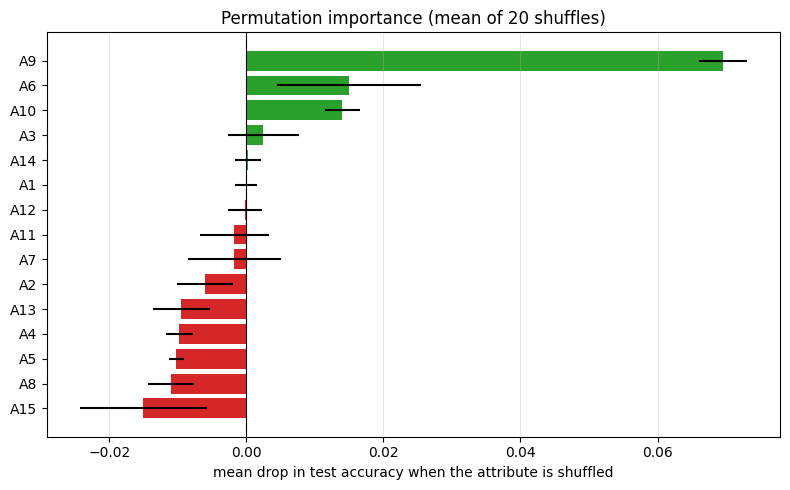

,attribute,acc_drop,acc_drop_std,f1_macro_drop
0,A9,0.0695,0.0035,0.0713
1,A6,0.0150,0.0105,0.0156
2,A10,0.0140,0.0025,0.0140
3,A3,0.0025,0.0051,0.0024
4,A14,0.0003,0.0019,0.0003
5,A1,0.0000,0.0016,-0.0000
6,A12,-0.0003,0.0025,-0.0003
7,A11,-0.0018,0.0051,-0.0022
8,A7,-0.0018,0.0068,-0.0018
9,A2,-0.0060,0.0041,-0.0061


In [25]:
# ---- permutation importance: shuffle each attribute, measure the performance drop ----
base = train_eval_cols(RAW)
perm_rng = np.random.default_rng(0)
N_PERM = 20

rows = []
for col in FEATURES:
    d_acc, d_f1 = [], []
    for _ in range(N_PERM):
        d = RAW.copy()
        d[col] = perm_rng.permutation(d[col].to_numpy())     # break col <-> label link
        s = train_eval_cols(d)
        d_acc.append(base["accuracy"] - s["accuracy"])
        d_f1.append(base["f1_macro"] - s["f1_macro"])
    rows.append((col, np.mean(d_acc), np.std(d_acc), np.mean(d_f1)))

perm = (pd.DataFrame(rows, columns=["attribute", "acc_drop", "acc_drop_std", "f1_macro_drop"])
        .sort_values("acc_drop", ascending=False).reset_index(drop=True))
print(f"baseline accuracy = {base['accuracy']:.3f}   (positive drop = attribute helps the model)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm["attribute"], perm["acc_drop"], xerr=perm["acc_drop_std"],
        color=np.where(perm["acc_drop"] >= 0, "tab:green", "tab:red"))
ax.axvline(0, c="black", lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("mean drop in test accuracy when the attribute is shuffled")
ax.set_title(f"Permutation importance (mean of {N_PERM} shuffles)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

perm.round(4)